# Ridge Regression Technique

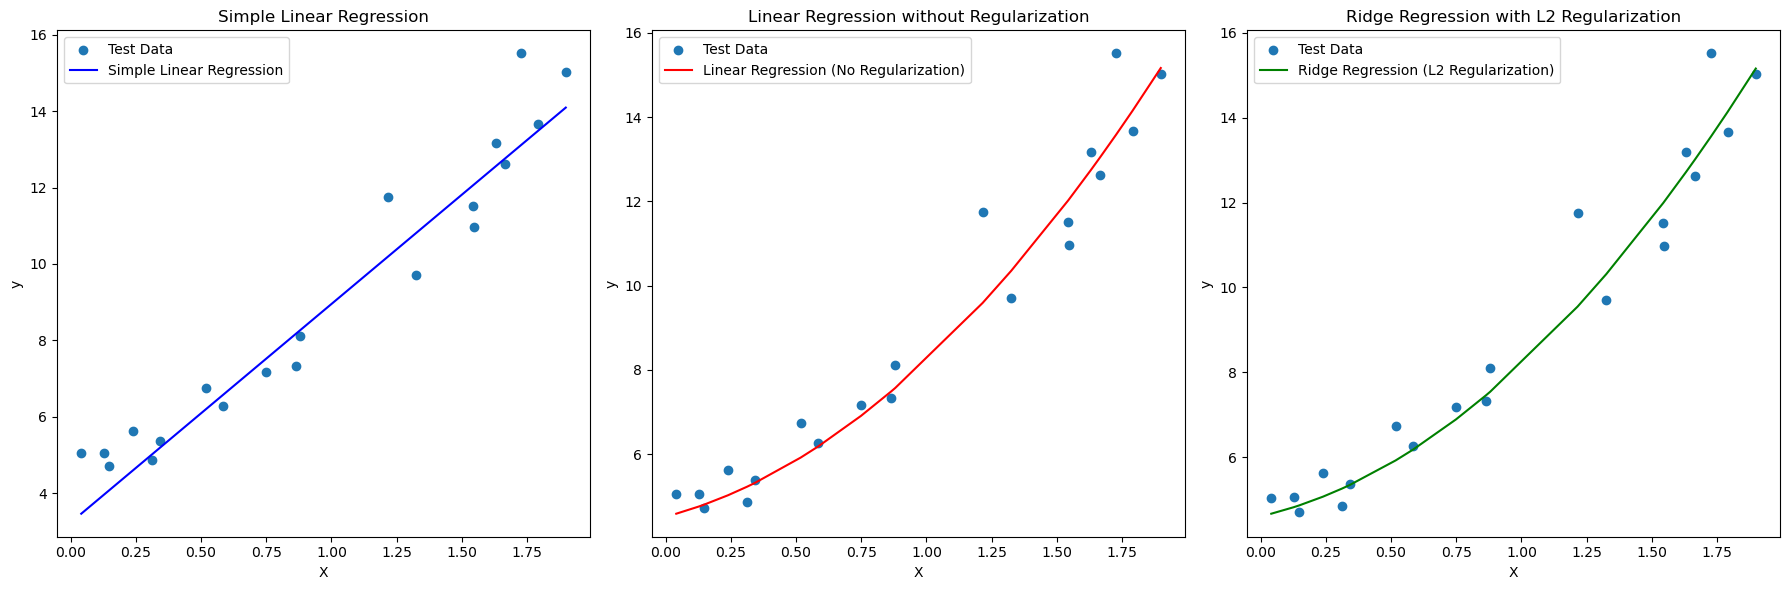

Mean Squared Error (Simple Linear Regression): 0.9382041612470866
Mean Squared Error (Linear Regression): 0.6358406072820796
Mean Squared Error (Ridge Regression): 0.6340644504857249


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Generate synthetic data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + 1.5 * X**2 + np.random.randn(100, 1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polynomial features (degree=2)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# Linear regression without regularization (Ordinary Least Squares)
ols_reg = LinearRegression()
ols_reg.fit(X_train_poly, y_train)

# Ridge Regression with L2 regularization
alpha = 1.0  # Regularization strength
ridge_reg = Ridge(alpha=alpha)
ridge_reg.fit(X_train_poly, y_train)

# Simple Linear Regression with first-degree polynomial
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

# Predictions on the test set
y_test_ols_pred = ols_reg.predict(X_test_poly)
y_test_ridge_pred = ridge_reg.predict(X_test_poly)
y_test_linear_pred = linear_reg.predict(X_test)

# Evaluate models on the test set
mse_ols = mean_squared_error(y_test, y_test_ols_pred)
mse_ridge = mean_squared_error(y_test, y_test_ridge_pred)
mse_linear = mean_squared_error(y_test, y_test_linear_pred)

# Plot the results
plt.figure(figsize=(18, 6))

# Plotting Simple Linear Regression
plt.subplot(1, 3, 1)
plt.scatter(X_test, y_test, label='Test Data')
plt.plot(np.sort(X_test, axis=0), linear_reg.predict(np.sort(X_test, axis=0)), color='blue', label='Simple Linear Regression')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

# Plotting Linear Regression without regularization
plt.subplot(1, 3, 2)
plt.scatter(X_test, y_test, label='Test Data')
plt.plot(np.sort(X_test, axis=0), ols_reg.predict(poly_features.transform(np.sort(X_test, axis=0))), color='red', label='Linear Regression (No Regularization)')
plt.title('Linear Regression without Regularization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

# Plotting Ridge Regression with L2 regularization
plt.subplot(1, 3, 3)
plt.scatter(X_test, y_test, label='Test Data')
plt.plot(np.sort(X_test, axis=0), ridge_reg.predict(poly_features.transform(np.sort(X_test, axis=0))), color='green', label='Ridge Regression (L2 Regularization)')
plt.title('Ridge Regression with L2 Regularization')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

# Print mean squared errors
print(f'Mean Squared Error (Simple Linear Regression): {mse_linear}')
print(f'Mean Squared Error (Linear Regression): {mse_ols}')
print(f'Mean Squared Error (Ridge Regression): {mse_ridge}')
